In [1]:
import rospy
import actionlib
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Button, Output, VBox, HBox, Label
from IPython.display import display, clear_output
import time
from assignment_2_2024.msg import PlanningAction, PlanningGoal, PlanningFeedback
from assignment_2_2024.msg import PoseVel
from assignment_2_2024.srv import GetLastGoal, GetLastGoalResponse
from nav_msgs.msg import Odometry
from matplotlib.animation import FuncAnimation
from sensor_msgs.msg import LaserScan

# Initialize ROS node
rospy.init_node('jupyter_goal_client')

# Enable interactive plotting
%matplotlib widget

In [2]:
# Global variables for plotting and feedback
x_positions = []
y_positions = []
# Global variables initialization (should be at the top of your script)
closest_obstacle_distances = []  # Store all distance measurements
time_points = []                # Store corresponding timestamps
counter = 0                     # Simple counter for time tracking
reached_goals = 0
unreached_goals = 0
plot_initialized = False
fig, ax = None, None
stats_fig, stats_ax = None, None
ani = None
current_feedback = None
feedback_label = None

In [3]:
def init_plots():
    global fig, ax, stats_fig, stats_ax, obs_fig, obs_ax, plot_initialized, feedback_label
    global closest_obstacle_distances, time_points, counter  # Initialize tracking variables
    
    # Initialize data storage
    closest_obstacle_distances = []
    time_points = []
    counter = 0
    
    # Initialize trajectory plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_title("Robot Trajectory")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.grid(True)
    
    # Initialize statistics plot
    stats_fig, stats_ax = plt.subplots(figsize=(8, 4))
    stats_ax.set_title("Goal Achievement Statistics")
    stats_ax.set_ylabel("Count")
    stats_ax.grid(True)
    
    # Initialize obstacle distance plot (time-series)
    obs_fig, obs_ax = plt.subplots(figsize=(8, 6))
    obs_ax.set_title("Closest Obstacle Distance Over Time")
    obs_ax.set_xlabel("Time (steps)")
    obs_ax.set_ylabel("Distance (meters)")
    obs_ax.set_ylim(0, 5)  # Initial range (0-5 meters)
    obs_ax.set_xlim(0, 50)  # Initial time window (50 steps)
    obs_ax.grid(True)
    
    # Create feedback label
    feedback_label = Label(value="Feedback: Waiting for first update...")
    
    plot_initialized = True
    plt.ion()  # Turn on interactive mode
    #plt.show(block=False)
    #plt.pause(0.1)  # Small pause to allow windows to initialize

In [4]:
#Callback functions
def odom_callback(msg):
    global x_positions, y_positions
    x_positions.append(msg.pose.pose.position.x)
    y_positions.append(msg.pose.pose.position.y)
    
    # Limit the number of points to keep the plot manageable
    if len(x_positions) > 1000:
        x_positions = x_positions[-1000:]
        y_positions = y_positions[-1000:]

def update_feedback_display(feedback):
    global feedback_label, current_feedback
    current_feedback = feedback
    if feedback_label:
        feedback_text = f"Feedback:\nStatus: {feedback.stat}\n"
        feedback_text += f"Actual Position: x={feedback.actual_pose.position.x:.2f}, y={feedback.actual_pose.position.y:.2f}"
        feedback_label.value = feedback_text


def clbk_laser(laser_data):
    global closest_obstacle_distances, time_points, counter
    
    if not laser_data:
        return None
    
    counter += 1
    # Filter out invalid measurements (negative, zero, or infinite values)
    valid_distances = [d for d in laser_data.ranges if d > 0 and d != float('inf')]
    
    if valid_distances:  # Only proceed if we have valid distances
        current_distance = min(valid_distances)
        closest_obstacle_distances.append(current_distance)
        time_points.append(counter)
        return current_distance
    return None

In [5]:
#Plot update functions
def update_plot():
    global ax, x_positions, y_positions, current_feedback
    if not plot_initialized:
        return
    
    ax.clear()
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    
    # Plot trajectory
    ax.plot(x_positions, y_positions, 'b-', label='Trajectory')
    
    # Plot current position
    if len(x_positions) > 0:
        ax.plot(x_positions[-1], y_positions[-1], 'ro', label='Current Position')
    
    # Plot target position if available
    if current_feedback and hasattr(current_feedback, 'target_pose'):
        ax.plot(current_feedback.target_pose.pose.position.x, 
                current_feedback.target_pose.pose.position.y, 
                'g*', markersize=10, label='Target Position')
    
    ax.legend()
    fig.canvas.draw()

def update_stats_plot():
    global stats_ax, reached_goals, unreached_goals
    if not plot_initialized:
        return
        
    stats_ax.clear()
    categories = ['Reached', 'Unreached']
    counts = [reached_goals, unreached_goals]
    bars = stats_ax.bar(categories, counts, color=['green', 'red'])
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        stats_ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom')
    
    stats_ax.set_title("Goal Achievement Statistics")
    stats_ax.set_ylabel("Count")
    stats_fig.canvas.draw()

def update_obstacle_distance_plot():
    global obs_ax, closest_obstacle_distances, time_points, obs_fig
    
    if not plot_initialized or len(time_points) < 1:
        return
    
    obs_ax.clear()
    
    # Keep all the same plot configurations
    obs_ax.set_title("Closest Obstacle Distance Over Time")
    obs_ax.set_xlabel("Time (steps)")
    obs_ax.set_ylabel("Distance (meters)")
    obs_ax.grid(True)
    
    # Dynamic axis scaling
    if closest_obstacle_distances:
        current_dist = closest_obstacle_distances[-1]
        y_max = max(5, current_dist * 1.5)  # At least 5m, or 1.5x current
        obs_ax.set_ylim(0, y_max)
        
        # Show last 50 time steps
        x_min = max(0, time_points[-1] - 50)
        x_max = max(50, time_points[-1] + 5)
        obs_ax.set_xlim(x_min, x_max)
        
        # Plot the data
        obs_ax.plot(time_points, closest_obstacle_distances, 'r-', linewidth=2, label='Distance')
        obs_ax.legend()
        
        # Add current value annotation
        obs_ax.annotate(f'{current_dist:.2f}m', 
                       xy=(time_points[-1], current_dist),
                       xytext=(10, 10), 
                       textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
    
    obs_fig.canvas.draw()
    obs_fig.canvas.flush_events()  # Important for interactive mode

    
def animate(i):
    try:
        update_plot()
        update_stats_plot()
        # Only update obstacle plot every 3 frames to reduce load
        if i % 3 == 0:
            update_obstacle_distance_plot()
    except Exception as e:
        print(f"Animation error: {e}")

In [6]:
#Action Client class with feedback
class JupyterGoalClient:
    def __init__(self):
        rospy.loginfo("Waiting for action server...")
        self.client = actionlib.SimpleActionClient('/reaching_goal', PlanningAction)
        self.client.wait_for_server()
        rospy.loginfo("Connected to action server.")

        self.last_goal_x = None
        self.last_goal_y = None
        self.current_goal = None
        
        # Services and subscribers
        self.last_goal_service = rospy.Service('/get_last_goal', GetLastGoal, self.handle_last_goal_request)
        self.odom_sub = rospy.Subscriber('/odom', Odometry, odom_callback)
        self.laser_scan = rospy.Subscriber('/scan', LaserScan, clbk_laser)
        self.pub = rospy.Publisher('/custom_odom', PoseVel, queue_size=10)

    def send_goal(self, x, y):
        goal = PlanningGoal()
        goal.target_pose.pose.position.x = x
        goal.target_pose.pose.position.y = y
        
        self.last_goal_x = x
        self.last_goal_y = y
        self.current_goal = goal
        
        self.client.send_goal(goal, feedback_cb=self.handle_feedback)
        rospy.loginfo(f"Goal sent: x={x}, y={y}")
        return True

    def cancel_goal(self):
        self.client.cancel_goal()
        self.last_goal_x = 10000
        self.last_goal_y = 10000
        self.current_goal = None
        rospy.loginfo("Goal cancelled")
        return True

    def handle_feedback(self, feedback):
        global unreached_goals, reached_goals
        
        # Update feedback display
        update_feedback_display(feedback)
        
        # Check goal status
        if feedback.stat == "Target reached!":
            reached_goals += 1
        elif feedback.stat == "Target cancelled!":
            unreached_goals += 1

    def handle_last_goal_request(self, req):
        if self.last_goal_x is None or self.last_goal_y is None:
            return GetLastGoalResponse(x=float('nan'), y=float('nan'))
        return GetLastGoalResponse(x=self.last_goal_x, y=self.last_goal_y)

[INFO] [1747084668.196235, 1207.932000]: Waiting for action server...
[INFO] [1747084668.260848, 1207.986000]: Connected to action server.


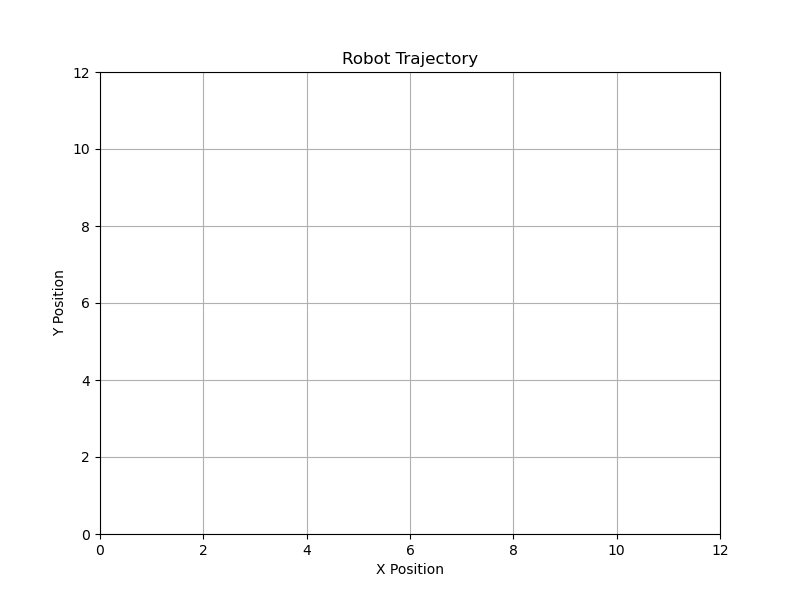

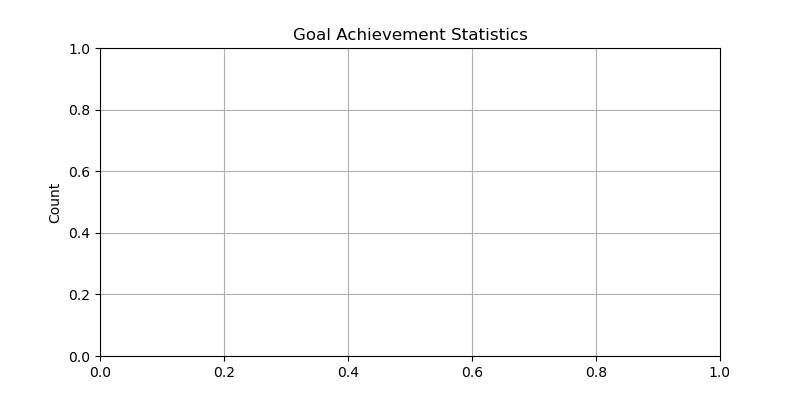

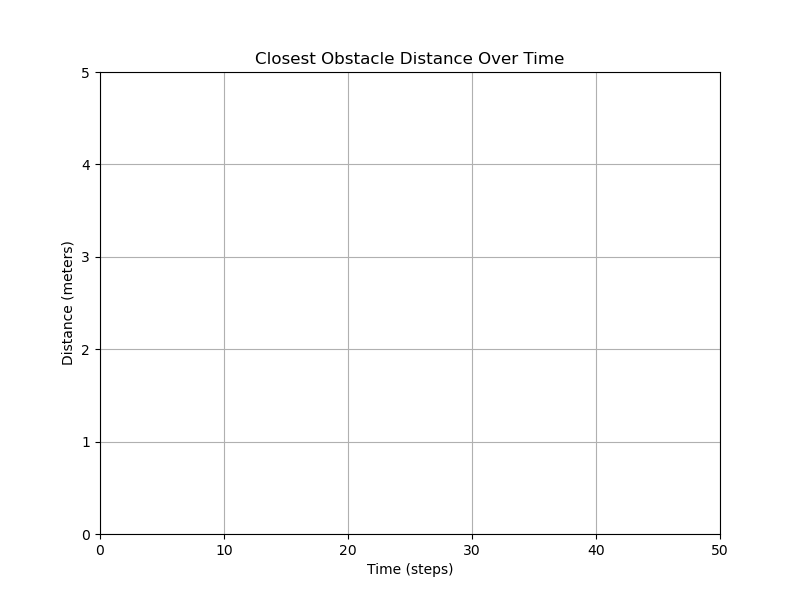

In [7]:
#Widget setup and display
# Initialize plots first
init_plots()

# Create animation after plots are initialized
ani = FuncAnimation(fig, animate, interval=1000)

# Create widgets for user interaction
x_slider = FloatSlider(min=0, max=11, step=0.1, value=5, description='Goal X:')
y_slider = FloatSlider(min=0, max=11, step=0.1, value=5, description='Goal Y:')
send_button = Button(description='Send Goal')
cancel_button = Button(description='Cancel Goal')
output = Output()

# Button click handlers
def on_send_click(b):
    with output:
        clear_output(wait=True)
        success = client.send_goal(x_slider.value, y_slider.value)
        if success:
            print(f"Goal successfully sent: x={x_slider.value}, y={y_slider.value}")
        else:
            print("Failed to send goal")

def on_cancel_click(b):
    with output:
        clear_output(wait=True)
        success = client.cancel_goal()
        if success:
            print("Goal successfully cancelled")
        else:
            print("Failed to cancel goal")

send_button.on_click(on_send_click)
cancel_button.on_click(on_cancel_click)

# Create the client
client = JupyterGoalClient()

# Display all widgets
display(VBox([
    x_slider,
    y_slider,
    HBox([send_button, cancel_button]),
    feedback_label,
    output
]))